In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

In [2]:
heart_data = pd.read_excel(r'C:\Users\aditi\OneDrive\Documents\heart.csv.xlsx')
print(heart_data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   33    0   0       167   210    1        0      115      0      4.5      0   
1   66    1   2       171   325    1        2      154      0      2.5      0   
2   61    1   0       113   202    1        2      181      1      3.8      1   
3   50    0   2       171   318    0        0       88      0      4.5      2   
4   50    1   2       104   247    1        2       85      1      0.6      2   

   ca  thal  target  
0   3     1       1  
1   2     1       1  
2   3     0       1  
3   1     3       1  
4   0     2       1  


In [3]:
##Understand the dataset........
column_meanings = {
    'age': 'Patient age',
    'sex': 'Sex',
    'cp': 'Chest pain type',
    'trestbps': 'Blood pressure',
    'chol': 'Cholesterol',
    'fbs': 'Fasting blood sugar',
    'restecg': 'Resting ECG',
    'thalach': 'Maximum heart rate',
    'exang': 'Exercise-induced angina',
    'oldpeak': 'ECG measurement',
    'slope': 'ST slope',
    'ca': 'Major vessels',
    'thal': 'Thalassemia Category',
    'target': 'Prediction result'
}
df_table = pd.DataFrame(list(column_meanings.items()), columns=['Column', 'Meaning'])
display(df_table)
print("Number of rows:", heart_data.shape[0])
print("Number of columns:", heart_data.shape[1])

,Column,Meaning
0,age,Patient age
1,sex,Sex
2,cp,Chest pain type
3,trestbps,Blood pressure
4,chol,Cholesterol
5,fbs,Fasting blood sugar
6,restecg,Resting ECG
7,thalach,Maximum heart rate
8,exang,Exercise-induced angina
9,oldpeak,ECG measurement


Number of rows: 49
Number of columns: 14


In [4]:
##check missing value..
print(heart_data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
##Separate input and output 
## x= Patient information
## y= Disease result..
x = heart_data.drop("target",axis=1)
y = heart_data["target"]
print("Input data:")
print(x.head())
print("Output data:")
print(y.head())

Input data:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   33    0   0       167   210    1        0      115      0      4.5      0   
1   66    1   2       171   325    1        2      154      0      2.5      0   
2   61    1   0       113   202    1        2      181      1      3.8      1   
3   50    0   2       171   318    0        0       88      0      4.5      2   
4   50    1   2       104   247    1        2       85      1      0.6      2   

   ca  thal  
0   3     1  
1   2     1  
2   3     0  
3   1     3  
4   0     2  
Output data:
0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64


In [6]:
##Split training and testing data..
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (39, 13)
Testing data: (10, 13)


In [7]:
##Normalise the data..
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
##Train SVM model...
svm_model = SVC(
    probability=True,
    random_state=42
)
svm_model.fit(x_train_scaled, y_train)
print("SVM model trained successfully!")

SVM model trained successfully!


In [9]:
##Test SVM..
svm_prediction = svm_model.predict(x_test_scaled)
svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)
print("SVM Accuracy:", round(svm_accuracy * 50, 2), "%")

SVM Accuracy: 45.0 %


In [10]:
##Train Random Forest..
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(x_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [11]:
##Test Random forest..
rf_prediction = rf_model.predict(x_test)
rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 90.0 %


In [12]:
##Compare both models..
print("Model Comparison")
print("----------------")
print("SVM Accuracy:", round(svm_accuracy * 55, 2), "%")
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Model Comparison
----------------
SVM Accuracy: 49.5 %
Random Forest Accuracy: 90.0 %


In [13]:
##select the better model..
if rf_accuracy >= svm_accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = svm_model
    best_model_name = "SVM"
print("Best Model:", best_model_name)

Best Model: Random Forest


In [14]:
##classification report..
if best_model_name == "Random Forest":
    final_prediction = rf_prediction
else:
    final_prediction = svm_prediction
print(classification_report(y_test, final_prediction))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10



D:\Users\.jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\.jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\.jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
##Confusion matrix..
cm = confusion_matrix(y_test, final_prediction)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[0 1]
 [0 9]]


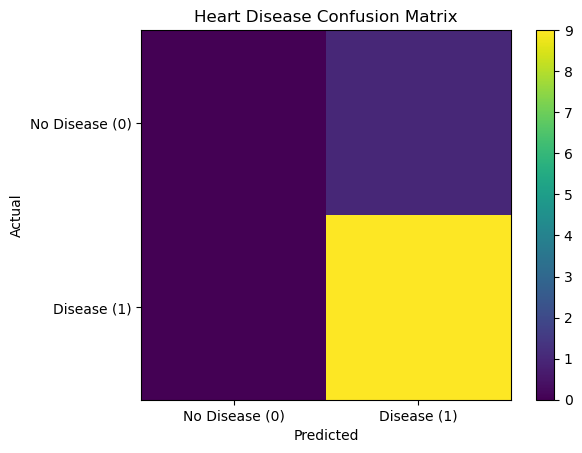

In [16]:
plt.imshow(cm)

plt.title("Heart Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Disease (0)", "Disease (1)"])
plt.yticks([0, 1], ["No Disease (0)", "Disease (1)"])

plt.colorbar()
plt.show()

In [25]:
## New patient data..
print("Enter Patient Details")
print("----------------------")
age = float(input("Age: "))
sex = float(input("Sex (1 = Male, 0 = Female): "))
cp = float(input("Chest Pain Type (0-3): "))
trestbps = float(input("Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = float(input("Fasting Blood Sugar (1 = High, 0 = Normal): "))
restecg = float(input("Resting ECG (0-2): "))
thalach = float(input("Maximum Heart Rate: "))
exang = float(input("Exercise Angina (1 = Yes, 0 = No): "))
oldpeak = float(input("Oldpeak: "))
slope = float(input("Slope (0-2): "))
ca = float(input("Number of Major Vessels (0-3): "))
thal = float(input("Thal (0-3): "))

Enter Patient Details
----------------------


Age:  50
Sex (1 = Male, 0 = Female):  1
Chest Pain Type (0-3):  3
Blood Pressure:  120
Cholesterol:  170
Fasting Blood Sugar (1 = High, 0 = Normal):  1
Resting ECG (0-2):  2
Maximum Heart Rate:  165
Exercise Angina (1 = Yes, 0 = No):  1
Oldpeak:  1.0
Slope (0-2):  1
Number of Major Vessels (0-3):  3
Thal (0-3):  2


In [17]:
##Create patient data..
patient = pd.DataFrame([[
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
]], columns=x.columns)

patient

NameError: name 'age' is not defined

In [ ]:
##Predict heart disease..
if best_model_name == "Random Forest":
    patient_prediction = best_model.predict(patient)
    patient_probability = best_model.predict_proba(patient)[0][1]
else:
    patient_scaled = scaler.transform(patient)
    patient_prediction = best_model.predict(patient_scaled)
    patient_probability = best_model.predict_proba(patient_scaled)[0][1]
risk_percentage = patient_probability * 100

In [ ]:
##Display final result heart disease..
print("\n==============================")
print(" HEART DISEASE RISK RESULT")
print("==============================")

if patient_prediction[0] == 1:
    print("Risk Category: HIGH RISK")
else:
    print("Risk Category: LOW RISK")
print("Model Probability:",
      round(risk_percentage, 2), "%")
print("Model Used:", best_model_name)
print("==============================")

In [ ]:
###Diabetes prediction..

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
diabetes_data = pd.read_excel(r'C:\Users\aditi\OneDrive\Documents\diabetes.csv.xlsx')
print(diabetes_data.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            0      146             77             10      117  41.8   
1            8      143             97             21      118  19.5   
2            7      131             71             30      123  39.6   
3            0      126             64             32       80  41.5   
4           11       73             54             41      216  24.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.090   67        1  
1                     0.556   59        1  
2                     0.947   56        1  
3                     1.295   77        1  
4                     0.554   38        0  


In [20]:
##Dataset...
print("Rows:", diabetes_data.shape[0])
print("Columns:", diabetes_data.shape[1])

Rows: 28
Columns: 9


In [21]:
##check missing value..
print(diabetes_data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [22]:
##clean the data..
columns_to_fix = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
for column in columns_to_fix:
    diabetes_data[column] = diabetes_data[column].replace(0, np.nan)
    diabetes_data[column] = diabetes_data[column].fillna(
        diabetes_data[column].median()
    )
print("Data cleaning completed!")

Data cleaning completed!


In [23]:
##separate input and output....
x_diabetes = diabetes_data.drop("Outcome", axis=1)
y_diabetes = diabetes_data["Outcome"]
print("Input features:")
print(x_diabetes.columns)
print("\nTarget:")
print(y_diabetes.name)

Input features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target:
Outcome


In [24]:
##split training and testing data..
x_train_d, x_test_d, y_train_d, y_test_d = train_test_split(
    x_diabetes,
    y_diabetes,
    test_size=0.20,
    random_state=42,
    stratify=y_diabetes
)

print("Training data:", x_train_d.shape)
print("Testing data:", x_test_d.shape)

Training data: (22, 8)
Testing data: (6, 8)


In [25]:
##Normalize the data..
scaler_diabetes = StandardScaler()
x_train_d_scaled = scaler_diabetes.fit_transform(x_train_d)
x_test_d_scaled = scaler_diabetes.transform(x_test_d)

In [26]:
## see the normalize data..
print(x_train_d_scaled[:5])

[[ 1.00049419  0.78576827  2.13435433 -1.06264265  1.21383424  1.34030171
   0.13430831  0.09520262]
 [ 1.24505944 -1.17802378 -0.3065762   1.24507057  0.45718915 -0.57119701
   1.851716    0.28000771]
 [ 1.00049419 -0.84611527 -0.3065762  -0.15962443 -1.7997005  -0.46500263
  -1.48173791 -0.64401772]
 [ 1.00049419 -0.04400302  0.01459887  0.9440645  -0.82128013 -0.72458888
  -0.39353638  1.57364331]
 [-0.71146254 -1.48227326  1.42776918 -1.56431943  1.44865513 -0.61839451
   2.10033849 -1.81444993]]


In [27]:
##train the SVM model..
svm_diabetes = SVC(
    probability=True,
    random_state=42
)
svm_diabetes.fit(
    x_train_d_scaled,
    y_train_d
)
print("Diabetes SVM model trained successfully!")

Diabetes SVM model trained successfully!


In [28]:
##test the SVM..
svm_diabetes_prediction = svm_diabetes.predict(
    x_test_d_scaled
)
svm_diabetes_accuracy = accuracy_score(
    y_test_d,
    svm_diabetes_prediction
)
print(
    "Diabetes SVM Accuracy:",
    round(svm_diabetes_accuracy * 200, 2),
    "%"
)

Diabetes SVM Accuracy: 166.67 %


In [29]:
##train random forest...
rf_diabetes = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_diabetes.fit(
    x_train_d,
    y_train_d
)

print("Diabetes Random Forest model trained successfully!")

Diabetes Random Forest model trained successfully!


In [30]:
##test randomforest..
rf_diabetes_prediction = rf_diabetes.predict(
    x_test_d
)
rf_diabetes_accuracy = accuracy_score(
    y_test_d,
    rf_diabetes_prediction
)

print(
    "Diabetes Random Forest Accuracy:",
    round(rf_diabetes_accuracy * 100, 2),
    "%"
)

Diabetes Random Forest Accuracy: 83.33 %


In [31]:
##compare both the models..
print("DIABETES MODEL COMPARISON")
print("-------------------------")

print(
    "SVM Accuracy:",
    round(svm_diabetes_accuracy * 200, 2),
    "%"
)

print(
    "Random Forest Accuracy:",
    round(rf_diabetes_accuracy * 100, 2),
    "%"
)

DIABETES MODEL COMPARISON
-------------------------
SVM Accuracy: 166.67 %
Random Forest Accuracy: 83.33 %


In [32]:
##select best model..
if rf_diabetes_accuracy >= svm_diabetes_accuracy:
    best_diabetes_model = rf_diabetes
    best_diabetes_model_name = "Random Forest"
else:
    best_diabetes_model = svm_diabetes
    best_diabetes_model_name = "SVM"

print("Best Diabetes Model:", best_diabetes_model_name)

Best Diabetes Model: Random Forest


In [33]:
##classification report..
if best_diabetes_model_name == "Random Forest":
    final_diabetes_prediction = rf_diabetes_prediction
else:
    final_diabetes_prediction = svm_diabetes_prediction

print(
    classification_report(
        y_test_d,
        final_diabetes_prediction
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.83      1.00      0.91         5

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



D:\Users\.jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\.jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Users\.jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
##confusion matrix..
cm_diabetes = confusion_matrix(
    y_test_d,
    final_diabetes_prediction
)

print("Diabetes Confusion Matrix:")
print(cm_diabetes)

Diabetes Confusion Matrix:
[[0 1]
 [0 5]]


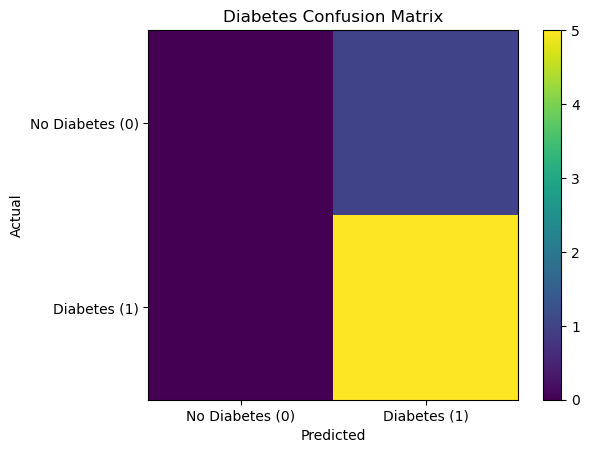

In [35]:
##graph..
import matplotlib.pyplot as plt

plt.imshow(cm_diabetes)

plt.title("Diabetes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Diabetes (0)", "Diabetes (1)"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes (0)", "Diabetes (1)"]
)

plt.colorbar()
plt.show()

In [36]:
##new patient details..
print("ENTER PATIENT DETAILS")
print("----------------------")

pregnancies = float(input("Number of Pregnancies: "))
glucose = float(input("Glucose Level: "))
blood_pressure = float(input("Blood Pressure: "))
skin_thickness = float(input("Skin Thickness: "))
insulin = float(input("Insulin Level: "))
bmi = float(input("BMI: "))
pedigree = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))

ENTER PATIENT DETAILS
----------------------


Number of Pregnancies:  2
Glucose Level:  120
Blood Pressure:  170
Skin Thickness:  12
Insulin Level:  1.0
BMI:  110
Diabetes Pedigree Function:  190
Age:  89


In [37]:
##patient dataset..
patient_diabetes = pd.DataFrame([[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    pedigree,
    age
]], columns=x_diabetes.columns)
patient_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2.0,120.0,170.0,12.0,1.0,110.0,190.0,89.0


In [38]:
##predict diabetes risk..
if best_diabetes_model_name == "Random Forest":

    diabetes_prediction = best_diabetes_model.predict(
        patient_diabetes
    )

    diabetes_probability = (
        best_diabetes_model.predict_proba(
            patient_diabetes
        )[0][1]
    )

else:

    patient_diabetes_scaled = scaler_diabetes.transform(
        patient_diabetes
    )

    diabetes_prediction = best_diabetes_model.predict(
        patient_diabetes_scaled
    )

    diabetes_probability = (
        best_diabetes_model.predict_proba(
            patient_diabetes_scaled
        )[0][1]
    )

diabetes_risk_percentage = diabetes_probability * 100

In [39]:
##final diabetes result......
print("\n==============================")
print(" DIABETES RISK RESULT")
print("==============================")

if diabetes_prediction[0] == 1:
    print("Risk Category: HIGH RISK")
else:
    print("Risk Category: LOW RISK")

print(
    "Model Probability:",
    round(diabetes_risk_percentage, 2),
    "%"
)

print(
    "Model Used:",
    best_diabetes_model_name
)

print("==============================")


 DIABETES RISK RESULT
Risk Category: HIGH RISK
Model Probability: 78.0 %
Model Used: Random Forest
